# Predicting Prolonged ICU Length of Stay Using First-Day Clinical Data

## Project Overview

This project uses the MIMIC-IV v3.1 critical care database to develop a machine learning model that predicts whether an ICU stay will exceed 5 days.

The prediction is based only on information available during the first 24 hours of ICU admission, including demographics, admission characteristics, vital signs, laboratory values, neurologic status, urine output, respiratory support, and vasoactive medication use.

The goal is to create a clinically meaningful prediction model while practicing real-world data extraction, SQL, exploratory data analysis, preprocessing, machine learning, model interpretation, and deployment.

## Data Source and Cohort Construction

The source data were obtained from the MIMIC-IV v3.1 database through Google BigQuery.

SQL was used to combine information from multiple relational tables, including:

- ICU stays
- Hospital admissions
- Patient demographics
- First-day vital signs
- First-day laboratory values
- First-day Glasgow Coma Scale
- First-day urine output
- Mechanical ventilation and respiratory support
- Vasoactive medication use

The analytic cohort was restricted to the first ICU stay within each hospital admission.

Patients who died during the hospitalization were excluded because an early death could otherwise be incorrectly classified as a short, non-prolonged ICU stay.

## Cohort Definition

This analysis uses a 24-hour landmark design.

Patients were included only if they remained in the ICU for at least 24 hours.
Clinical information collected during the first 24 hours of ICU admission was used
to predict whether the total ICU length of stay would exceed 5 days.

Patients with ICU stays shorter than 24 hours were excluded because they were no
longer at risk at the 24-hour prediction landmark.

The final cohort contains 59,809 ICU stays from 47,974 unique patients.

Outcome:
- 0 = ICU stay of 1–5 days
- 1 = ICU stay >5 days

The positive-class prevalence is approximately 19.5%.

## Outcome Definition

The target variable is:

**Prolonged ICU stay = ICU length of stay greater than 5 days**

The final 24-hour landmark cohort contains:

- 59,809 ICU stays
- 48,122 non-prolonged ICU stays
- 11,687 prolonged ICU stays
- 19.54% positive class prevalence

Each row represents one ICU stay.

## Initial Data Validation

Before beginning the exploratory analysis, the exported dataset was checked to confirm that:

- The expected number of ICU stays was preserved after export
- Each ICU stay appears only once
- The target distribution matches the SQL-derived cohort
- Column types and missing values were imported correctly

Identifier columns such as `subject_id`, `hadm_id`, and `stay_id` will not be used as model predictors.

The `los` variable is retained only for descriptive and validation purposes because it directly defines the target and would otherwise create target leakage.

In [604]:
import pandas as pd

df = pd.read_csv("../data/raw/icu_prolonged_los_final_v2.csv")

In [605]:
df.shape

(59809, 45)

In [606]:
df.columns.tolist()

['subject_id',
 'hadm_id',
 'stay_id',
 'prolonged_icu_stay',
 'los',
 'age',
 'gender',
 'race',
 'admission_type',
 'admission_location',
 'first_careunit',
 'heart_rate_min',
 'heart_rate_max',
 'heart_rate_mean',
 'sbp_min',
 'sbp_mean',
 'mbp_min',
 'mbp_mean',
 'resp_rate_max',
 'resp_rate_mean',
 'temperature_min',
 'temperature_max',
 'spo2_min',
 'spo2_mean',
 'hemoglobin_min',
 'platelets_min',
 'wbc_max',
 'bicarbonate_min',
 'bun_max',
 'creatinine_max',
 'glucose_max',
 'sodium_min',
 'sodium_max',
 'potassium_min',
 'potassium_max',
 'inr_max',
 'gcs_min',
 'urine_output_24h',
 'invasive_vent_24h',
 'invasive_vent_at_24h',
 'noninvasive_vent_24h',
 'hfnc_24h',
 'tracheostomy_24h',
 'any_vasoactive_24h',
 'vasoactive_agent_count_24h']

In [607]:
df["prolonged_icu_stay"].value_counts(normalize=True)

prolonged_icu_stay
0    0.804595
1    0.195405
Name: proportion, dtype: float64

In [608]:
df[["invasive_vent_24h", "invasive_vent_at_24h"]].value_counts().sort_index()

invasive_vent_24h  invasive_vent_at_24h
0                  0                       37789
1                  0                       12119
                   1                        9901
Name: count, dtype: int64

In [609]:
df.head()

,subject_id,hadm_id,stay_id,prolonged_icu_stay,los,age,gender,race,admission_type,admission_location,...,inr_max,gcs_min,urine_output_24h,invasive_vent_24h,invasive_vent_at_24h,noninvasive_vent_24h,hfnc_24h,tracheostomy_24h,any_vasoactive_24h,vasoactive_agent_count_24h
0,14823881,20886388,33624004,0,1.009664,70,F,WHITE,OBSERVATION ADMIT,TRANSFER FROM HOSPITAL,...,NaN,15.0,2645.0,0,0,0,0,0,1,1
1,15846912,26187595,37370226,0,2.766667,29,F,WHITE,EW EMER.,EMERGENCY ROOM,...,NaN,14.0,1150.0,0,0,0,0,0,0,0
2,11236633,24126826,33769887,1,35.585822,26,F,WHITE - OTHER EUROPEAN,EW EMER.,INFORMATION NOT AVAILABLE,...,NaN,15.0,750.0,1,1,0,0,0,1,1
3,12032603,24633889,35450930,0,2.103472,83,F,WHITE,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,...,1.1,12.0,950.0,0,0,0,0,0,0,0
4,18072939,20234062,36318698,0,2.555868,81,F,WHITE - RUSSIAN,OBSERVATION ADMIT,PHYSICIAN REFERRAL,...,1.0,15.0,NaN,0,0,0,0,0,0,0


In [610]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59809 entries, 0 to 59808
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   subject_id                  59809 non-null  int64  
 1   hadm_id                     59809 non-null  int64  
 2   stay_id                     59809 non-null  int64  
 3   prolonged_icu_stay          59809 non-null  int64  
 4   los                         59809 non-null  float64
 5   age                         59809 non-null  int64  
 6   gender                      59809 non-null  str    
 7   race                        59809 non-null  str    
 8   admission_type              59809 non-null  str    
 9   admission_location          59809 non-null  str    
 10  first_careunit              59809 non-null  str    
 11  heart_rate_min              59749 non-null  float64
 12  heart_rate_max              59749 non-null  float64
 13  heart_rate_mean             59749 non-null

In [611]:
df["prolonged_icu_stay"].value_counts(normalize=True)

prolonged_icu_stay
0    0.804595
1    0.195405
Name: proportion, dtype: float64

In [612]:
df["stay_id"].duplicated().sum()

np.int64(0)

### Initial Validation Results

Dataset contains 59,809 ICU stays and 45 columns.

There are no duplicated ICU stay identifiers.

Approximately 19.5% of ICU stays meet the definition of prolonged ICU stay (>5 days), producing an imbalanced binary classification problem.


# Descriptive Analysis
In this section, we summarize the main characteristics of the dataset before performing detailed exploratory analysis.

The goals are to:

- Identify the numerical and categorical predictors
- Summarize distributions using descriptive statistics
- Evaluate missing data
- Examine category frequencies
- Look for implausible values or extreme outliers
- Understand the degree of class imbalance in the target

No rows or variables will be removed at this stage. The goal is first to understand the data before making preprocessing decisions.

In [613]:
id_cols = ["subject_id", "hadm_id", "stay_id"]
target_col = "prolonged_icu_stay"

categorical_cols = [
    "gender",
    "race",
    "admission_type",
    "admission_location",
    "first_careunit"
]

exclude_from_model = id_cols + [target_col, "los"]

numerical_cols = [
    col
    for col in df.columns
    if col not in categorical_cols + exclude_from_model
]

In [614]:
print("Number of categorical predictors:", len(categorical_cols))
print("Number of numerical predictors:", len(numerical_cols))
print("Total predictors:", len(categorical_cols) + len(numerical_cols))

Number of categorical predictors: 5
Number of numerical predictors: 35
Total predictors: 40


### Predictor Groups

The model predictors are divided into two broad groups:

- **Categorical predictors:** variables such as gender, race, admission type, admission location, and ICU type.
- **Numerical predictors:** age, vital signs, laboratory values, neurologic measures, urine output, and ICU-support variables.

The identifier columns (`subject_id`, `hadm_id`, and `stay_id`) are excluded because they identify encounters rather than describe patient physiology.

The `los` variable is also excluded because it directly determines the target variable and would cause target leakage.

In [615]:
numerical_summary = df[numerical_cols].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
age,59809.0,64.444248,16.539478,18.000000,55.000000,66.000000,77.000000,103.000000
heart_rate_min,59749.0,69.639073,14.667975,1.000000,60.000000,68.000000,79.000000,163.000000
heart_rate_max,59749.0,102.768436,20.181252,36.000000,88.000000,100.000000,115.000000,295.000000
heart_rate_mean,59749.0,84.084373,15.448290,28.500000,73.280000,82.578947,93.681818,174.740741
sbp_min,59730.0,92.278297,16.369832,1.000000,82.000000,91.000000,102.000000,181.000000
sbp_mean,59730.0,118.773799,16.062325,62.941176,107.181818,116.347826,128.458333,206.388889
mbp_min,59734.0,60.274735,13.225580,0.830000,53.000000,60.000000,68.000000,126.000000
mbp_mean,59734.0,79.429638,11.124962,42.863636,71.619846,77.791667,85.905878,151.529412
resp_rate_max,59662.0,27.840465,6.346751,9.000000,23.500000,27.000000,31.000000,69.000000
resp_rate_mean,59662.0,18.916398,3.607612,8.695652,16.396678,18.342481,20.846154,42.000000


### Numerical Descriptive Statistics

The table above summarizes the central tendency and spread of each numerical predictor.

Important values to review include:

- **mean** and **median** to assess skewness
- **standard deviation** to assess variability
- **minimum and maximum** to identify potentially implausible values
- **25th and 75th percentiles** to understand the typical range

Clinical variables are often not normally distributed, particularly laboratory values and measures of illness severity, so large differences between the mean and median may indicate skewed distributions.

In [616]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- gender ---
gender
M    33905
F    25904
Name: count, dtype: int64

--- race ---
race
WHITE                                        37724
BLACK/AFRICAN AMERICAN                        5342
UNKNOWN                                       5039
OTHER                                         2020
WHITE - OTHER EUROPEAN                        1481
UNABLE TO OBTAIN                              1178
HISPANIC/LATINO - PUERTO RICAN                 780
ASIAN                                          684
ASIAN - CHINESE                                649
WHITE - RUSSIAN                                579
HISPANIC/LATINO - DOMINICAN                    511
HISPANIC OR LATINO                             482
BLACK/CAPE VERDEAN                             408
BLACK/CARIBBEAN ISLAND                         383
PATIENT DECLINED TO ANSWER                     373
BLACK/AFRICAN                                  273
PORTUGUESE                                     263
ASIAN - SOUTH EAST ASIAN                   

### Categorical Variable Distribution

Categorical predictors are reviewed to identify:

- dominant categories
- rare categories
- missing or unknown categories
- variables that may require grouping before one-hot encoding

Variables with many rare categories, particularly race and admission location, may later be simplified to reduce model complexity and unstable estimates.

In [617]:
missing_summary = pd.DataFrame({
    "missing_count": df[numerical_cols + categorical_cols].isna().sum(),
    "missing_percent": (
        df[numerical_cols + categorical_cols]
        .isna()
        .mean()
        .mul(100)
    )
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
inr_max,5562,9.299604
urine_output_24h,1978,3.307195
temperature_min,1598,2.671839
temperature_max,1598,2.671839
glucose_max,588,0.983130
potassium_max,433,0.723971
potassium_min,433,0.723971
platelets_min,410,0.685516
hemoglobin_min,408,0.682172
wbc_max,407,0.680500


### Missing Data

Missing data are common in ICU datasets because laboratory tests and clinical measurements are obtained according to clinical need rather than according to a fixed research protocol.

Most predictors in the current analytic dataset have relatively low missingness.

The variables with the greatest missingness are:

- INR: approximately 9.3%
- Urine output: approximately 3.3%
- Temperature: approximately 2.7%

Most remaining variables have less than 1% missing data.

Rows were not removed simply because individual predictor values were missing. Missing numerical values are handled using median imputation within the machine-learning pipeline, while categorical variables use most-frequent imputation.

### Descriptive Analysis: Initial Findings

The dataset contains 40 candidate predictors: 35 numerical and 5 categorical variables.

Several observations are important before preprocessing:

1. Most physiological and laboratory variables have relatively little missing data.
2. INR has the highest missingness at approximately 9.3%.
3. Urine output is missing in approximately 3.3% of ICU stays.
4. Temperature measurements are missing in approximately 2.7% of ICU stays.
5. Several numerical variables contain extreme values that may represent true severe physiology, measurement error, charting error, or data-processing artifacts.
6. Some categorical variables contain relatively uncommon groups and should therefore be interpreted cautiously.

These findings guide the cleaning and preprocessing strategy used before model development.

### Potential Outliers and Data Quality

Several numerical predictors contain extreme values.

In critical-care datasets, extreme values can arise from:

- true severe physiology
- measurement artifacts
- unit errors
- documentation errors
- corrected chart entries
- aggregation of unusual source data

Extreme observations should therefore not automatically be removed. Their distributions will first be examined to distinguish plausible clinical extremes from clearly implausible values.

In [618]:
quantiles = df[numerical_cols].quantile(
    [0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
).T

quantiles

,0.001,0.010,0.050,0.500,0.950,0.990,0.999
age,19.000000,22.000000,32.000000,66.000000,89.000000,92.000000,97.000000
heart_rate_min,28.000000,39.000000,48.000000,68.000000,96.000000,109.000000,125.000000
heart_rate_max,55.000000,65.000000,74.000000,100.000000,139.000000,160.000000,190.252000
heart_rate_mean,42.611897,53.035074,61.215058,82.578947,111.797647,125.078523,140.194300
sbp_min,30.000000,55.000000,68.000000,91.000000,121.000000,137.000000,154.000000
sbp_mean,80.190725,90.063085,96.790575,116.347826,148.540224,163.835965,181.834843
mbp_min,1.000000,15.000000,40.000000,60.000000,82.000000,93.000000,106.000000
mbp_mean,52.783833,58.539519,64.034483,77.791667,100.202414,110.686087,125.194228
resp_rate_max,15.000000,18.000000,20.000000,27.000000,40.000000,48.000000,63.000000
resp_rate_mean,10.925926,12.564067,14.080000,18.342481,25.720000,29.826087,35.312349


In [619]:
outlier_check_cols = [
    "heart_rate_min",
    "heart_rate_max",
    "sbp_min",
    "mbp_min",
    "temperature_min",
    "temperature_max",
    "spo2_min",
    "wbc_max",
    "creatinine_max",
    "glucose_max",
    "potassium_max",
    "urine_output_24h"
]

df[outlier_check_cols].describe(
    percentiles=[0.001, 0.01, 0.05, 0.95, 0.99, 0.999]
).T

,count,mean,std,min,0.1%,1%,5%,95%,99%,99.9%,max
heart_rate_min,59749.0,69.639073,14.667975,1.00,28.0000,39.00,48.00,96.00,109.00,125.0000,163.0
heart_rate_max,59749.0,102.768436,20.181252,36.00,55.0000,65.00,74.00,139.00,160.00,190.2520,295.0
sbp_min,59730.0,92.278297,16.369832,1.00,30.0000,55.00,68.00,121.00,137.00,154.0000,181.0
mbp_min,59734.0,60.274735,13.225580,0.83,1.0000,15.00,40.00,82.00,93.00,106.0000,126.0
temperature_min,58211.0,36.328094,0.648105,15.00,31.1000,34.11,35.20,37.00,37.39,37.9400,39.8
temperature_max,58211.0,37.376147,0.655840,31.60,35.2021,36.28,36.67,38.72,39.50,40.2200,42.3
spo2_min,59737.0,91.878573,5.456541,0.30,36.0000,72.00,84.00,98.00,99.00,100.0000,100.0
wbc_max,59402.0,13.803521,10.000769,0.10,0.3000,2.90,5.20,26.40,38.90,113.3193,451.2
creatinine_max,59451.0,1.529934,1.798203,0.10,0.3000,0.40,0.50,4.50,9.50,16.9550,80.0
glucose_max,59221.0,167.652860,114.249893,7.00,58.0000,77.00,90.00,332.00,664.00,1273.2400,4560.0


### Outlier Review

Extreme values were reviewed using percentile-based summaries rather than relying only on minimum and maximum values.

In ICU data, very abnormal measurements may represent genuine severe illness and should not automatically be removed. However, some values are physiologically implausible and are more likely to represent charting errors, measurement artifacts, or unit inconsistencies.

The preprocessing strategy will therefore:

- retain clinically plausible extreme values
- convert clearly implausible values to missing values
- impute those missing values later within the machine-learning pipeline
- avoid aggressive outlier removal that could discard clinically important information

In [620]:
import numpy as np

clean_df = df.copy()

# Clearly implausible vital-sign values
clean_df.loc[clean_df["heart_rate_min"] < 20, "heart_rate_min"] = np.nan
clean_df.loc[clean_df["heart_rate_max"] > 250, "heart_rate_max"] = np.nan

clean_df.loc[clean_df["sbp_min"] < 30, "sbp_min"] = np.nan
clean_df.loc[clean_df["mbp_min"] < 20, "mbp_min"] = np.nan

clean_df.loc[clean_df["temperature_min"] < 25, "temperature_min"] = np.nan
clean_df.loc[clean_df["temperature_max"] > 45, "temperature_max"] = np.nan

clean_df.loc[clean_df["spo2_min"] < 20, "spo2_min"] = np.nan

# Implausibly high potassium
clean_df.loc[clean_df["potassium_max"] > 12, "potassium_max"] = np.nan

# Negative urine output is not physiologically meaningful
clean_df.loc[clean_df["urine_output_24h"] < 0, "urine_output_24h"] = np.nan

In [621]:
checks = {
    "heart_rate_min < 20": (df["heart_rate_min"] < 20).sum(),
    "heart_rate_max > 250": (df["heart_rate_max"] > 250).sum(),
    "sbp_min < 30": (df["sbp_min"] < 30).sum(),
    "mbp_min < 20": (df["mbp_min"] < 20).sum(),
    "temperature_min < 25": (df["temperature_min"] < 25).sum(),
    "temperature_max > 45": (df["temperature_max"] > 45).sum(),
    "spo2_min < 20": (df["spo2_min"] < 20).sum(),
    "potassium_max > 12": (df["potassium_max"] > 12).sum(),
    "urine_output_24h < 0": (df["urine_output_24h"] < 0).sum(),
    "wbc_max > 100": (df["wbc_max"] > 100).sum(),
    "creatinine_max > 20": (df["creatinine_max"] > 20).sum(),
    "glucose_max > 1000": (df["glucose_max"] > 1000).sum()
}

checks

{'heart_rate_min < 20': np.int64(13),
 'heart_rate_max > 250': np.int64(3),
 'sbp_min < 30': np.int64(59),
 'mbp_min < 20': np.int64(729),
 'temperature_min < 25': np.int64(7),
 'temperature_max > 45': np.int64(0),
 'spo2_min < 20': np.int64(39),
 'potassium_max > 12': np.int64(2),
 'urine_output_24h < 0': np.int64(10),
 'wbc_max > 100': np.int64(69),
 'creatinine_max > 20': np.int64(31),
 'glucose_max > 1000': np.int64(154)}

### Review of Extreme Values

Most extreme observations are uncommon.

Some values may represent true severe critical illness and should not be automatically removed. In particular, profound hypotension, severe leukocytosis, renal failure, marked hyperglycemia, and extreme heart rates can occur in critically ill patients.

A conservative cleaning strategy will therefore be used. Only values that are clearly physiologically implausible or incompatible with the measurement definition will initially be converted to missing values. Other extreme observations will be retained unless further inspection suggests that they are erroneous.

In [622]:
df.loc[
    (df["sbp_min"] < 30),
    [
        "stay_id",
        "sbp_min",
        "sbp_mean",
        "mbp_min",
        "mbp_mean",
        "heart_rate_mean",
        "prolonged_icu_stay"
    ]
].sort_values("sbp_min").head(20)

,stay_id,sbp_min,sbp_mean,mbp_min,mbp_mean,heart_rate_mean,prolonged_icu_stay
32550,39010522,1.000,128.954545,57.0,81.476190,84.391304,0
5093,38737830,1.000,146.727273,73.0,93.285714,75.115385,0
41140,33744429,2.000,124.320000,67.0,79.520000,70.440000,0
21087,31971781,2.000,121.125000,75.0,87.652174,90.280000,0
59299,38756665,3.000,122.161290,65.0,79.206897,63.333333,0
53692,34923584,4.000,115.740741,53.0,74.807692,85.750000,1
15809,35499050,5.000,103.000000,57.0,75.962963,81.884615,1
1456,33467688,6.000,96.794872,3.0,60.564103,94.111111,0
31035,35713201,7.000,89.846154,57.5,65.520000,114.130435,1
49934,33979198,7.000,108.960526,3.0,67.193333,58.920000,1


In [623]:
df.loc[
    (df["mbp_min"] < 20),
    [
        "stay_id",
        "sbp_min",
        "sbp_mean",
        "mbp_min",
        "mbp_mean",
        "heart_rate_mean",
        "prolonged_icu_stay"
    ]
].sort_values("mbp_min").head(20)

,stay_id,sbp_min,sbp_mean,mbp_min,mbp_mean,heart_rate_mean,prolonged_icu_stay
54997,35746627,88.0,111.400000,0.83,73.455000,81.807692,1
33225,34337300,89.0,112.102564,1.00,76.675000,88.615385,0
52620,38413909,109.0,133.566667,1.00,100.551724,116.692308,1
30420,35181557,112.0,137.796875,1.00,83.352941,65.948718,1
52738,37258853,30.0,114.672414,1.00,86.793103,114.655172,0
12438,39987914,101.0,119.041667,1.00,83.062500,79.347826,0
12652,35380841,88.0,111.125000,1.00,73.173913,80.500000,1
30781,35629978,77.0,107.659091,1.00,69.329545,95.233333,1
13128,37129984,64.0,105.686275,1.00,72.568627,105.500000,1
31102,34656214,86.0,107.000000,1.00,71.040000,62.500000,0


In [624]:
df.loc[
    (df["potassium_max"] > 12)
    | (df["creatinine_max"] > 20)
    | (df["glucose_max"] > 1000)
    | (df["wbc_max"] > 100),
    [
        "stay_id",
        "potassium_max",
        "creatinine_max",
        "glucose_max",
        "wbc_max",
        "prolonged_icu_stay"
    ]
].sort_values("glucose_max", ascending=False).head(30)

,stay_id,potassium_max,creatinine_max,glucose_max,wbc_max,prolonged_icu_stay
9855,32762015,7.1,1.9,4560.0,37.5,0
38757,36056611,4.4,1.1,3330.0,12.2,0
53989,35005058,4.6,1.2,3200.0,19.9,0
47781,34028838,4.1,1.0,3090.0,17.6,0
45816,30763023,4.4,1.9,2440.0,14.5,0
5995,38100564,6.9,5.7,2340.0,13.0,0
56744,38185691,4.2,1.3,2323.0,9.4,0
3373,35957799,5.6,2.0,2275.0,17.2,1
40109,31269898,8.7,0.9,2202.0,19.6,0
19442,30204256,7.0,0.9,2085.0,13.3,0


### Physiologic Plausibility Cleaning

Inspection of extreme observations showed that several minimum vital-sign values were inconsistent with the remaining measurements from the same ICU stay.

For example, some ICU stays contained a systolic blood pressure minimum close to zero despite normal mean systolic and mean arterial pressures. These values are most consistent with isolated measurement or documentation artifacts.

A conservative cleaning strategy was therefore used:

- Only clearly implausible measurements were converted to missing values.
- Other extreme but clinically possible measurements were retained.
- Entire patient records were not removed because of an isolated implausible measurement.
- Missing values introduced during cleaning will later be handled within the preprocessing pipeline.

This approach preserves clinically meaningful severe physiology while reducing the influence of obvious measurement artifacts.

In [625]:
cleaning_summary = pd.DataFrame({
    "original_missing": df.isna().sum(),
    "cleaned_missing": clean_df.isna().sum()
})

cleaning_summary["new_missing_from_cleaning"] = (
    cleaning_summary["cleaned_missing"]
    - cleaning_summary["original_missing"]
)

cleaning_summary[
    cleaning_summary["new_missing_from_cleaning"] > 0
].sort_values(
    "new_missing_from_cleaning",
    ascending=False
)

,original_missing,cleaned_missing,new_missing_from_cleaning
mbp_min,75,804,729
sbp_min,79,138,59
spo2_min,72,111,39
heart_rate_min,60,73,13
urine_output_24h,1978,1988,10
temperature_min,1598,1605,7
heart_rate_max,60,63,3
potassium_max,433,435,2


In [626]:
clean_df.shape

(59809, 45)

# Exploratory Data Analysis

After reviewing data quality, missingness, and extreme values, the next step is to explore how the predictors relate to the target outcome.

The target variable is:

- `0`: ICU length of stay 1–5 days
- `1`: ICU length of stay > 5 days

The goals of this section are to:

- compare clinical characteristics between prolonged and non-prolonged ICU stays
- identify variables that may be associated with prolonged ICU stay
- examine categorical and ICU-support variables
- visualize important numerical predictors
- identify potential redundancy or correlation between predictors

These analyses are exploratory. Associations observed here do not establish causation.

In [627]:
key_numeric_cols = [
    "age",
    "heart_rate_mean",
    "mbp_mean",
    "resp_rate_mean",
    "spo2_mean",
    "hemoglobin_min",
    "wbc_max",
    "bicarbonate_min",
    "bun_max",
    "creatinine_max",
    "glucose_max",
    "sodium_min",
    "potassium_max",
    "inr_max",
    "gcs_min",
    "urine_output_24h"
]

group_summary = (
    clean_df
    .groupby("prolonged_icu_stay")[key_numeric_cols]
    .agg(["median", "mean"])
    .T
)

group_summary

prolonged_icu_stay                 0            1
age              median    66.000000    65.000000
                 mean      64.638648    63.643792
heart_rate_mean  median    82.148148    84.739130
                 mean      83.510018    86.455950
mbp_mean         median    77.821429    77.685855
                 mean      79.430925    79.424325
resp_rate_mean   median    18.174457    19.181818
                 mean      18.691127    19.846175
spo2_mean        median    97.083333    97.240000
                 mean      96.935740    96.990125
hemoglobin_min   median    10.100000    10.000000
                 mean      10.169412    10.171480
wbc_max          median    12.000000    13.200000
                 mean      13.519616    14.975714
bicarbonate_min  median    22.000000    21.000000
                 mean      22.008434    21.439194
bun_max          median    19.000000    22.000000
                 mean      26.175733    29.790973
creatinine_max   median     1.000000     1.100000
                 mean       1.494179     1.677630
glucose_max      median   136.000000   150.000000
                 mean     165.580004   176.198166
sodium_min       median   137.000000   137.000000
                 mean     136.668102   136.819807
potassium_max    median     4.400000     4.500000
                 mean       4.552080     4.633469
inr_max          median     1.300000     1.300000
                 mean       1.515276     1.627417
gcs_min          median    15.000000    15.000000
                 mean      13.768621    13.304654
urine_output_24h median  1675.000000  1470.000000
                 mean    1908.540006  1745.729010

### Numerical Comparison by Outcome

Numerical variables were summarized separately for prolonged and non-prolonged ICU stays.

Both means and medians are shown. Medians are particularly useful for ICU variables because several clinical measurements have skewed distributions and extreme values.

Differences observed between the two groups will help identify candidate predictors, but these comparisons are descriptive rather than causal.

In [628]:
support_cols = [
    "invasive_vent_24h",
    "invasive_vent_at_24h",
    "noninvasive_vent_24h",
    "hfnc_24h",
    "tracheostomy_24h",
    "any_vasoactive_24h"
]

support_rates = (
    clean_df
    .groupby("prolonged_icu_stay")[support_cols]
    .mean()
    .T
    .mul(100)
)

support_rates.columns = [
    "Non-prolonged (%)",
    "Prolonged (%)"
]

support_rates

,Non-prolonged (%),Prolonged (%)
invasive_vent_24h,31.258052,59.707367
invasive_vent_at_24h,9.261876,46.581672
noninvasive_vent_24h,1.820373,1.942329
hfnc_24h,1.192802,2.900659
tracheostomy_24h,0.756411,0.607513
any_vasoactive_24h,25.096629,38.136391


### ICU Support During the First 24 Hours

The prevalence of major ICU therapies was compared between outcome groups.

These variables describe early illness severity and resource utilization, including:

- invasive mechanical ventilation
-invasive mechanical ventilation at the 24-hour landmark
- non-invasive ventilation
- high-flow nasal cannula
- tracheostomy
- vasoactive medication use

Because these variables are binary, their group means represent the proportion of ICU stays receiving each therapy.

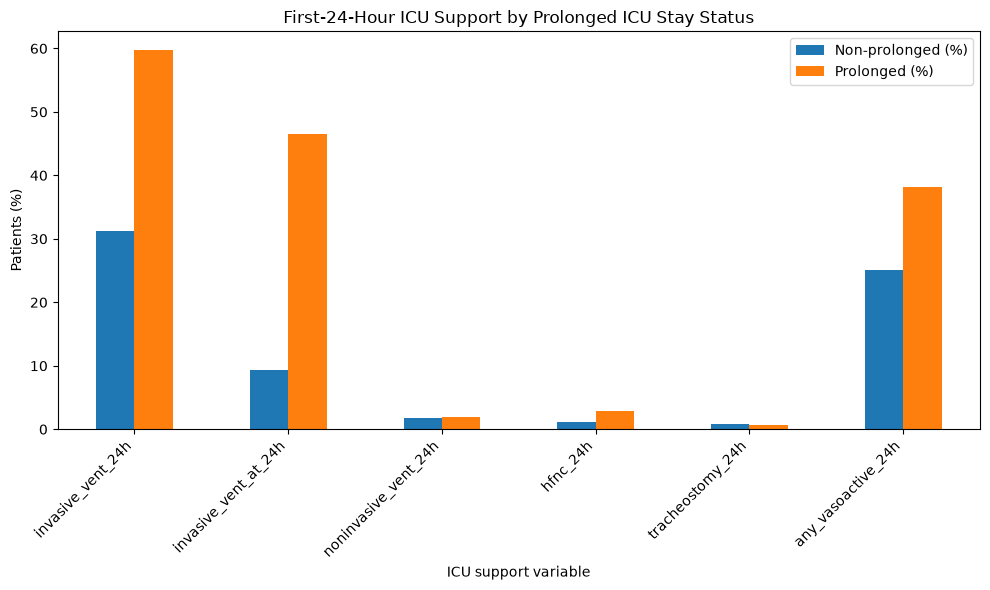

In [629]:
import matplotlib.pyplot as plt

support_rates.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Patients (%)")
plt.xlabel("ICU support variable")
plt.title("First-24-Hour ICU Support by Prolonged ICU Stay Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [630]:
clean_df.groupby("prolonged_icu_stay")[
    "vasoactive_agent_count_24h"
].describe()

,count,mean,std,min,25%,50%,75%,max
prolonged_icu_stay,,,,,,,,
0,48122.0,0.314368,0.610314,0.0,0.0,0.0,1.0,5.0
1,11687.0,0.615812,0.962278,0.0,0.0,0.0,1.0,6.0


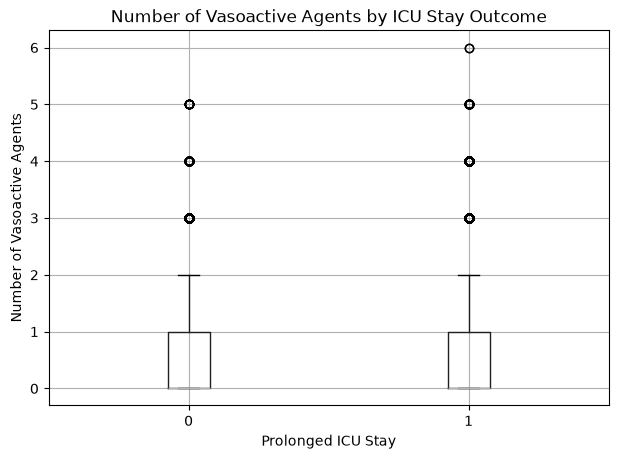

In [631]:
clean_df.boxplot(
    column="vasoactive_agent_count_24h",
    by="prolonged_icu_stay",
    figsize=(7, 5)
)

plt.title("Number of Vasoactive Agents by ICU Stay Outcome")
plt.suptitle("")
plt.xlabel("Prolonged ICU Stay")
plt.ylabel("Number of Vasoactive Agents")
plt.show()

In [632]:
vent_table = pd.crosstab(
    clean_df["invasive_vent_24h"],
    clean_df["prolonged_icu_stay"],
    normalize="columns"
) * 100

vent_table

prolonged_icu_stay,0,1
invasive_vent_24h,,
0,68.741948,40.292633
1,31.258052,59.707367


In [633]:
icu_outcomes = (
    clean_df
    .groupby("first_careunit")
    .agg(
        total_stays=("prolonged_icu_stay", "size"),
        prolonged_stays=("prolonged_icu_stay", "sum"),
        prolonged_rate=("prolonged_icu_stay", "mean")
    )
    .sort_values("total_stays", ascending=False)
)

icu_outcomes["prolonged_rate"] *= 100

icu_outcomes

,total_stays,prolonged_stays,prolonged_rate
first_careunit,,,
Medical Intensive Care Unit (MICU),11661,2438,20.907298
Cardiac Vascular Intensive Care Unit (CVICU),11658,1548,13.278435
Medical/Surgical Intensive Care Unit (MICU/SICU),8939,1307,14.621322
Surgical Intensive Care Unit (SICU),8051,1684,20.916656
Coronary Care Unit (CCU),6705,1184,17.658464
Trauma SICU (TSICU),6273,1317,20.994739
Neuro Intermediate,4398,1569,35.675307
Neuro Surgical Intensive Care Unit (Neuro SICU),981,233,23.751274
Neuro Stepdown,976,300,30.737705


### ICU Type and Prolonged Stay

Prolonged ICU-stay rates were compared across the first ICU care unit.

Differences between ICUs should be interpreted primarily as differences in case mix and patient severity rather than as measures of ICU performance.

For example, medical, surgical, cardiovascular, trauma, and neurologic ICUs care for substantially different patient populations.

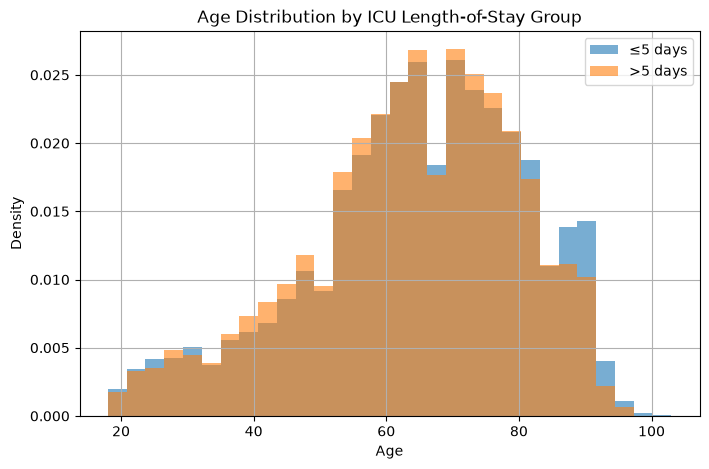

In [634]:
plt.figure(figsize=(8, 5))

clean_df[
    clean_df["prolonged_icu_stay"] == 0
]["age"].hist(
    bins=30,
    alpha=0.6,
    density=True,
    label="≤5 days"
)

clean_df[
    clean_df["prolonged_icu_stay"] == 1
]["age"].hist(
    bins=30,
    alpha=0.6,
    density=True,
    label=">5 days"
)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Age Distribution by ICU Length-of-Stay Group")
plt.legend()
plt.show()

### Key EDA Findings

Several clinically meaningful differences were observed between prolonged and non-prolonged ICU stays.

- Invasive mechanical ventilation during the first 24 hours was substantially more common among prolonged ICU stays.
- Vasoactive medication use was also more frequent in the prolonged-stay group.
- Prolonged stays were associated with modestly higher heart rate, respiratory rate, WBC count, BUN, creatinine, glucose, potassium, and INR.
- Prolonged stays showed somewhat lower hemoglobin, bicarbonate, GCS, and urine output.
- Age distributions overlapped substantially between outcome groups, suggesting that age alone is unlikely to strongly discriminate prolonged ICU stay.
- Prolonged-stay rates varied by ICU type, although these differences likely reflect differences in patient populations and case mix rather than ICU performance.
- Very small ICU categories produced unstable percentages and should be interpreted cautiously.

Overall, the exploratory findings suggest that early illness severity and intensity of organ support may be more informative than basic demographic characteristics for predicting prolonged ICU stay.

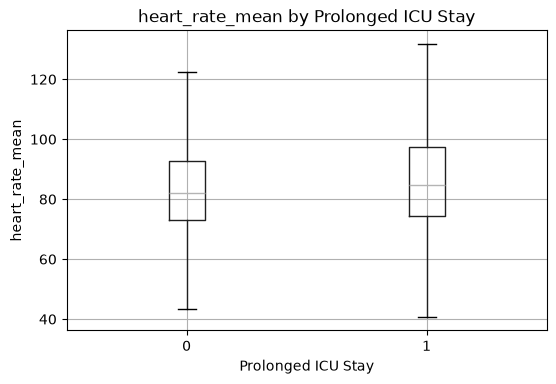

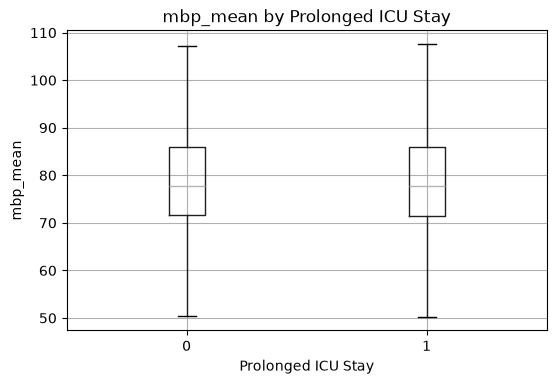

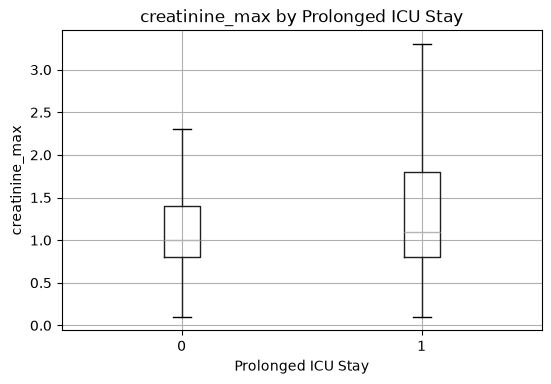

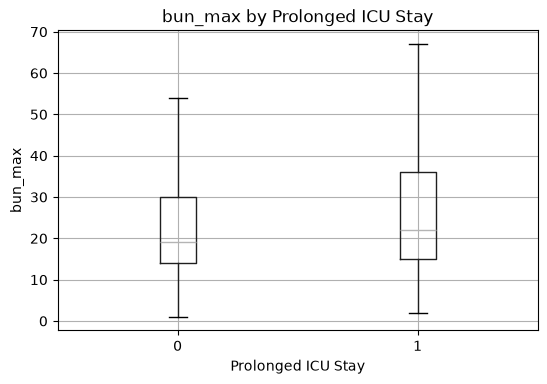

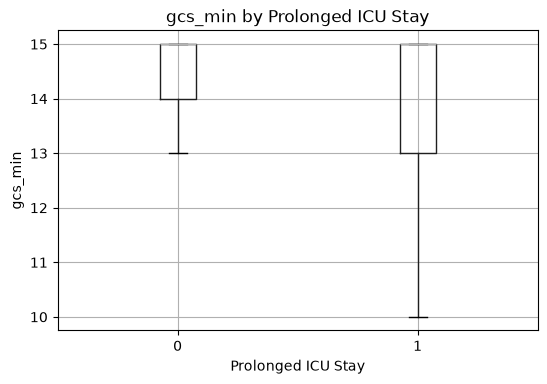

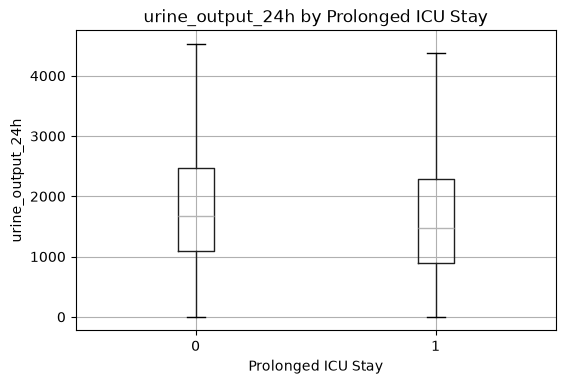

In [635]:
important_continuous = [
    "heart_rate_mean",
    "mbp_mean",
    "creatinine_max",
    "bun_max",
    "gcs_min",
    "urine_output_24h"
]

for col in important_continuous:
    clean_df.boxplot(
        column=col,
        by="prolonged_icu_stay",
        figsize=(6, 4),
        showfliers=False
    )
    plt.title(f"{col} by Prolonged ICU Stay")
    plt.suptitle("")
    plt.xlabel("Prolonged ICU Stay")
    plt.ylabel(col)
    plt.show()

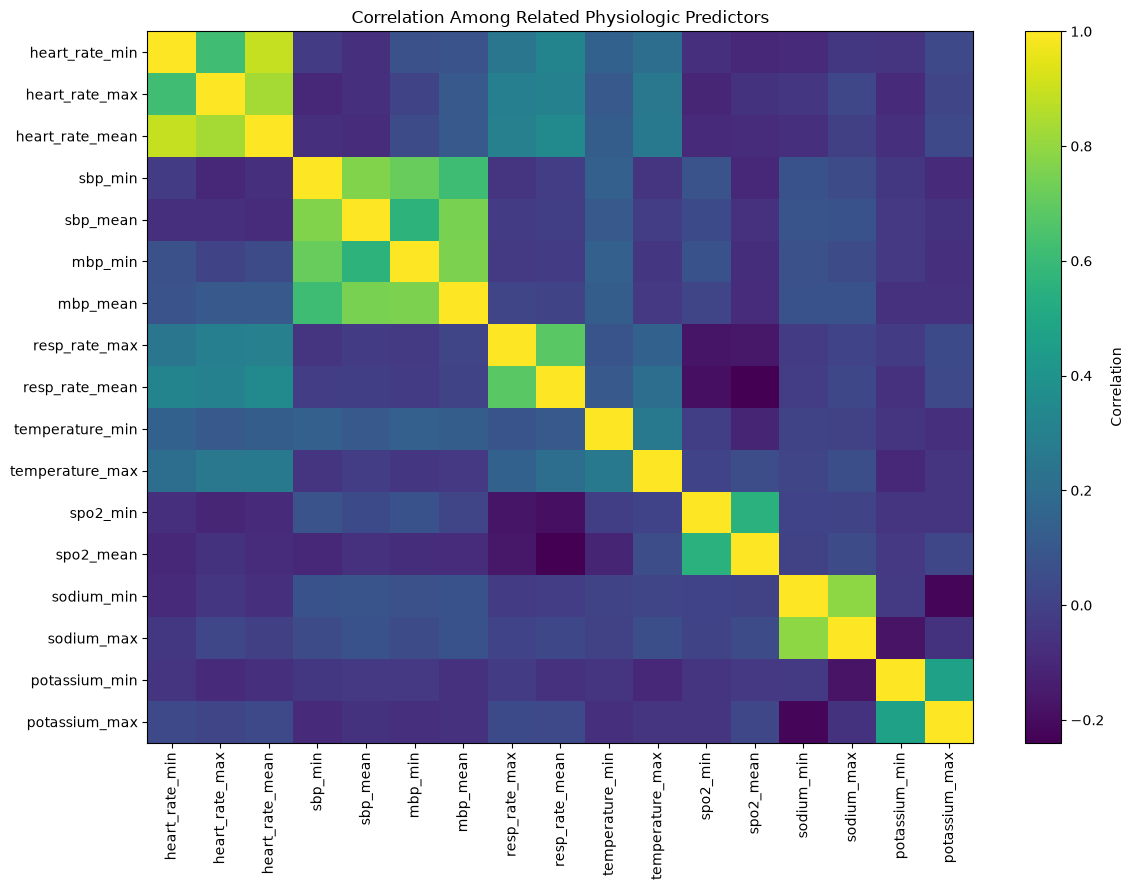

In [636]:
correlation_cols = [
    "heart_rate_min",
    "heart_rate_max",
    "heart_rate_mean",
    "sbp_min",
    "sbp_mean",
    "mbp_min",
    "mbp_mean",
    "resp_rate_max",
    "resp_rate_mean",
    "temperature_min",
    "temperature_max",
    "spo2_min",
    "spo2_mean",
    "sodium_min",
    "sodium_max",
    "potassium_min",
    "potassium_max"
]

corr = clean_df[correlation_cols].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=90)
plt.yticks(range(len(correlation_cols)), correlation_cols)
plt.title("Correlation Among Related Physiologic Predictors")
plt.tight_layout()
plt.show()

### Interpretation of Continuous Predictors and Correlation

The boxplots show substantial overlap between prolonged and non-prolonged ICU stays for most individual physiological variables. This suggests that prolonged ICU stay is unlikely to be explained by a single measurement and instead reflects a combination of multiple clinical factors.

Several variables showed modest shifts in the prolonged-stay group, including higher heart rate, BUN, creatinine, and lower GCS and urine output.

The correlation matrix also identified groups of related predictors. For example, minimum, maximum, and mean heart rate measurements were strongly correlated, as were related blood-pressure measures and minimum/maximum electrolyte values.

Highly correlated predictors may contain redundant information. This is particularly relevant for regression-based models, where multicollinearity can make coefficient estimates unstable. Tree-based models are generally more tolerant of correlated predictors, although reducing redundancy may still improve interpretability.

### Feature Simplification

Several vital-sign variables were available as minimum, maximum, and mean values over the first ICU day.

Because these measures were highly correlated, the feature set was simplified to reduce redundancy and improve interpretability.

For continuously monitored physiological variables such as heart rate, mean arterial pressure, respiratory rate, and oxygen saturation, the mean first-day value was selected as the primary summary measure.

For laboratory variables, clinically relevant minimum or maximum values were retained when the more abnormal extreme was likely to better reflect illness severity.

## Train/Test Split

To avoid patient-level data leakage, the dataset is split by `subject_id` rather than by individual ICU stays.

This ensures that all ICU stays belonging to the same patient are assigned entirely to either the training set or the test set.

The target variable is `prolonged_icu_stay`, and the selected predictors include demographic, physiologic, laboratory, neurologic, renal, respiratory-support, and vasoactive-support variables.

In [637]:
continuous_features = [
    "age",
    "heart_rate_mean",
    "mbp_mean",
    "resp_rate_mean",
    "spo2_mean",
    "hemoglobin_min",
    "platelets_min",
    "wbc_max",
    "bicarbonate_min",
    "bun_max",
    "creatinine_max",
    "glucose_max",
    "sodium_min",
    "potassium_max",
    "inr_max",
    "gcs_min",
    "urine_output_24h",
    "vasoactive_agent_count_24h"
]

binary_features = [
    "invasive_vent_24h",
    "invasive_vent_at_24h",
    "noninvasive_vent_24h",
    "hfnc_24h",
    "tracheostomy_24h",
    "any_vasoactive_24h"
]

final_categorical_features = [
    "gender",
    "admission_type",
    "admission_location",
    "first_careunit"
]

final_numeric_features = continuous_features + binary_features

feature_cols = (
    continuous_features
    + binary_features
    + final_categorical_features
)

print("Total predictors:", len(feature_cols))

Total predictors: 28


In [638]:
from sklearn.model_selection import GroupShuffleSplit

X = clean_df[feature_cols].copy()
y = clean_df["prolonged_icu_stay"].copy()
groups = clean_df["subject_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_subjects = clean_df.iloc[train_idx]["subject_id"]
test_subjects = clean_df.iloc[test_idx]["subject_id"]

In [639]:
overlap = set(train_subjects).intersection(set(test_subjects))

print("Patient overlap:", len(overlap))
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Patient overlap: 0
Training rows: 47797
Testing rows: 12012


In [640]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
prolonged_icu_stay
0    0.804988
1    0.195012
Name: proportion, dtype: float64

Testing target distribution:
prolonged_icu_stay
0    0.80303
1    0.19697
Name: proportion, dtype: float64


### Train/Test Split Strategy

The dataset was split by patient identifier (`subject_id`) rather than by individual ICU stays.

This prevents different ICU stays from the same patient from appearing in both the training and test sets, reducing patient-level data leakage.

`GroupShuffleSplit` was used to reserve 20% of the cohort for final testing.

Because `GroupShuffleSplit` does not explicitly stratify the outcome, the class distribution in the training and test sets was checked after splitting.

There was no overlap in patient identifiers between the training and test sets.

## Preprocessing Pipeline

The modeling dataset contains both numerical and categorical predictors, as well as some missing values.

To avoid data leakage, all preprocessing steps are learned from the training set only and then applied unchanged to the test set.

The preprocessing strategy is:

- numerical variables: median imputation
- categorical variables: most-frequent imputation if needed, followed by one-hot encoding
- scaling of numerical variables for models that are sensitive to feature scale, such as logistic regression

The preprocessing steps will be combined using a `ColumnTransformer` so that the same transformations can later be incorporated directly into the machine-learning pipeline.

In [641]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [642]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [643]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [644]:
binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

In [645]:
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", numeric_pipeline, continuous_features),
        ("binary", binary_pipeline, binary_features),
        ("categorical", categorical_pipeline, final_categorical_features)
    ]
)

### Continuous, Binary, and Categorical Predictors

The predictors were further divided into three groups:

- continuous numerical variables
- binary clinical-support indicators
- categorical variables

Continuous variables are median-imputed and standardized.

Binary variables are imputed if necessary but are not scaled because they already have a meaningful 0/1 representation.

Categorical variables are imputed and one-hot encoded.

This separation improves interpretability and avoids unnecessary transformation of binary clinical indicators.

## Cross-Validation Strategy

The preprocessing steps and machine-learning model will be combined into a single pipeline.

This is important because imputation, scaling, and one-hot encoding must be fitted separately within each training fold during cross-validation. If preprocessing were performed on the entire training dataset before cross-validation, information from the validation folds could leak into the preprocessing step.

A `StratifiedGroupKFold` strategy will be used so that:

- all ICU stays from the same patient remain within the same fold
- the proportion of prolonged ICU stays remains approximately similar across folds
- model selection and hyperparameter tuning are performed without using the final test set

In [646]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [647]:
groups_train = clean_df.iloc[train_idx]["subject_id"].reset_index(drop=True)

In [648]:
print("Training rows:", len(X_train))
print("Training groups:", len(groups_train))
print("Unique training patients:", groups_train.nunique())

Training rows: 47797
Training groups: 47797
Unique training patients: 38379


In [649]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

## Baseline Model: Logistic Regression

Logistic regression will be used as the first baseline model.

It is a useful starting point because it is relatively interpretable and provides a benchmark against which more complex models such as Random Forest and XGBoost can be compared.

Performance will be evaluated using group-aware cross-validation so that ICU stays from the same patient do not appear in both the training and validation portions of a fold.

Because the outcome is imbalanced, accuracy alone is not sufficient. We will focus on:

- ROC-AUC
- PR-AUC
- recall
- precision
- F1 score

In [650]:
from sklearn.model_selection import cross_validate

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

In [651]:
import pandas as pd

logistic_cv_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Recall",
        "Precision",
        "F1"
    ],
    "Mean CV Score": [
        logistic_cv_results["test_roc_auc"].mean(),
        logistic_cv_results["test_pr_auc"].mean(),
        logistic_cv_results["test_recall"].mean(),
        logistic_cv_results["test_precision"].mean(),
        logistic_cv_results["test_f1"].mean()
    ],
    "Std Dev": [
        logistic_cv_results["test_roc_auc"].std(),
        logistic_cv_results["test_pr_auc"].std(),
        logistic_cv_results["test_recall"].std(),
        logistic_cv_results["test_precision"].std(),
        logistic_cv_results["test_f1"].std()
    ]
})

logistic_cv_summary

,Metric,Mean CV Score,Std Dev
0,ROC-AUC,0.802387,0.008137
1,PR-AUC,0.557372,0.011404
2,Recall,0.341486,0.010743
3,Precision,0.652092,0.014145
4,F1,0.448195,0.011956


In [652]:
logistic_cv_results["test_roc_auc"]

array([0.8058906 , 0.81508641, 0.80186147, 0.79869279, 0.79040463])

## Random Forest Model

Random Forest will be evaluated as a nonlinear alternative to logistic regression.

Unlike logistic regression, Random Forest can naturally model nonlinear relationships and interactions between predictors without requiring them to be specified in advance.

For example, the effect of renal dysfunction may differ depending on whether a patient is mechanically ventilated or receiving vasoactive support.

The model will be evaluated using the same patient-grouped cross-validation strategy and the same performance metrics used for logistic regression.

In [653]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [654]:
rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

In [655]:
rf_cv_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Recall",
        "Precision",
        "F1"
    ],
    "Mean CV Score": [
        rf_cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_pr_auc"].mean(),
        rf_cv_results["test_recall"].mean(),
        rf_cv_results["test_precision"].mean(),
        rf_cv_results["test_f1"].mean()
    ],
    "Std Dev": [
        rf_cv_results["test_roc_auc"].std(),
        rf_cv_results["test_pr_auc"].std(),
        rf_cv_results["test_recall"].std(),
        rf_cv_results["test_precision"].std(),
        rf_cv_results["test_f1"].std()
    ]
})

rf_cv_summary

,Metric,Mean CV Score,Std Dev
0,ROC-AUC,0.817704,0.004886
1,PR-AUC,0.577352,0.008930
2,Recall,0.333547,0.007494
3,Precision,0.687749,0.011164
4,F1,0.449182,0.008115


In [656]:
rf_cv_results["test_roc_auc"]

array([0.81927083, 0.82634041, 0.81594533, 0.81482109, 0.81214412])

In [657]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [658]:
xgb_cv_results = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

In [659]:
xgb_cv_summary = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Recall",
        "Precision",
        "F1"
    ],
    "Mean CV Score": [
        xgb_cv_results["test_roc_auc"].mean(),
        xgb_cv_results["test_pr_auc"].mean(),
        xgb_cv_results["test_recall"].mean(),
        xgb_cv_results["test_precision"].mean(),
        xgb_cv_results["test_f1"].mean()
    ],
    "Std Dev": [
        xgb_cv_results["test_roc_auc"].std(),
        xgb_cv_results["test_pr_auc"].std(),
        xgb_cv_results["test_recall"].std(),
        xgb_cv_results["test_precision"].std(),
        xgb_cv_results["test_f1"].std()
    ]
})

xgb_cv_summary

,Metric,Mean CV Score,Std Dev
0,ROC-AUC,0.820291,0.007093
1,PR-AUC,0.582948,0.011035
2,Recall,0.370023,0.010209
3,Precision,0.669403,0.013863
4,F1,0.476577,0.011642


In [660]:
xgb_cv_results["test_roc_auc"]

array([0.82338666, 0.83224968, 0.81873416, 0.81519826, 0.81188777])

## Hyperparameter Optimization

XGBoost was selected as the primary model because it achieved the strongest cross-validated performance among the initial models.

Hyperparameter tuning will be performed using group-aware cross-validation so that all ICU stays from the same patient remain within the same fold.

The main hyperparameters to explore include:

- number of trees
- tree depth
- learning rate
- row subsampling
- feature subsampling

The optimization will focus primarily on ROC-AUC, while PR-AUC and other metrics will also be reviewed.

In [661]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.05, 0.1, 0.15],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [662]:
xgb_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.02, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoos

In [663]:
xgb_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 700,
 'model__max_depth': 4,
 'model__learning_rate': 0.02,
 'model__colsample_bytree': 0.7}

In [664]:
xgb_search.best_score_

np.float64(0.8214181597879948)

In [665]:
results = pd.DataFrame(xgb_search.cv_results_)

results[
    [
        "mean_test_score",
        "std_test_score",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__learning_rate",
        "param_model__subsample",
        "param_model__colsample_bytree"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree
13,0.821418,0.007102,700,4,0.02,0.7,0.7
7,0.821280,0.006496,200,6,0.05,0.7,0.8
14,0.820903,0.007210,500,5,0.05,0.9,1.0
3,0.820389,0.006685,200,5,0.05,0.9,0.9
16,0.819554,0.007197,300,4,0.10,1.0,1.0
12,0.819131,0.007177,200,6,0.02,0.8,0.7
10,0.818479,0.007044,200,6,0.02,0.9,0.9
17,0.818126,0.005987,700,6,0.05,0.8,0.8
2,0.818113,0.007131,200,3,0.15,1.0,0.9
1,0.817641,0.007351,300,5,0.02,1.0,0.9


## Final Evaluation on the Test Set

After model selection and hyperparameter optimization were completed using only the training data, the final tuned XGBoost model was evaluated once on the previously untouched test set.

This provides an estimate of how the finalized model performs on patients who were not used during model development.

The evaluation includes:

- ROC-AUC
- PR-AUC
- accuracy
- recall
- precision
- F1 score
- confusion matrix

The default probability threshold of 0.50 is used for classification metrics. The precision-recall curve is examined descriptively to illustrate the tradeoff between sensitivity and precision, but no classification threshold is optimized using the held-out test set.

In [666]:
best_xgb_model = xgb_search.best_estimator_

y_test_pred = best_xgb_model.predict(X_test)
y_test_prob = best_xgb_model.predict_proba(X_test)[:, 1]

In [667]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

test_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "Recall",
        "Precision",
        "F1"
    ],
    "Test Score": [
        roc_auc_score(y_test, y_test_prob),
        average_precision_score(y_test, y_test_prob),
        accuracy_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred)
    ]
})

test_metrics

,Metric,Test Score
0,ROC-AUC,0.824250
1,PR-AUC,0.586217
2,Accuracy,0.837413
3,Recall,0.350803
4,Precision,0.665597
5,F1,0.459452


In [668]:
confusion_matrix(y_test, y_test_pred)

array([[9229,  417],
       [1536,  830]])

In [669]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.90      9646
           1       0.67      0.35      0.46      2366

    accuracy                           0.84     12012
   macro avg       0.76      0.65      0.68     12012
weighted avg       0.82      0.84      0.82     12012



In [670]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

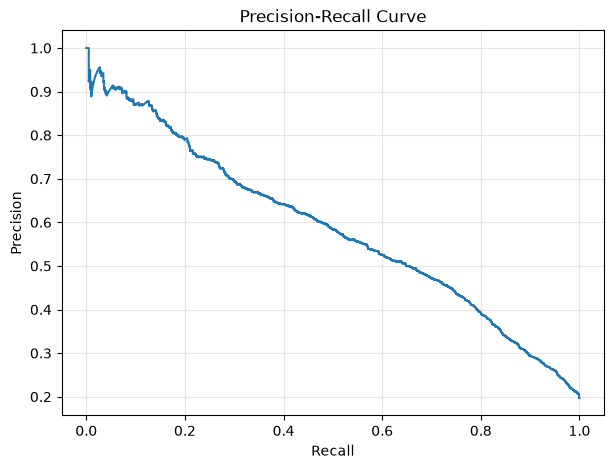

In [671]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)

plt.show()

### Precision-Recall Tradeoff

The precision-recall curve demonstrates the expected tradeoff between sensitivity and positive predictive value.

Lower probability thresholds identify a larger proportion of true prolonged ICU stays but generate more false-positive predictions.

Higher thresholds increase precision but miss more patients with prolonged stays.

The default threshold of 0.50 is therefore not inherently optimal. Threshold selection should depend on the intended use of the model and the relative importance of false-negative and false-positive predictions.

## Calibration Analysis

Discrimination metrics such as ROC-AUC and PR-AUC measure how well the model separates higher-risk from lower-risk patients.

Calibration asks a different question:

> When the model predicts a certain probability of prolonged ICU stay, does that probability correspond to the observed event rate?

For example, among patients assigned a predicted risk of approximately 30%, a well-calibrated model should ideally show an observed prolonged-stay rate close to 30%.

Calibration is especially important when model probabilities may eventually be used for clinical risk communication or decision support.

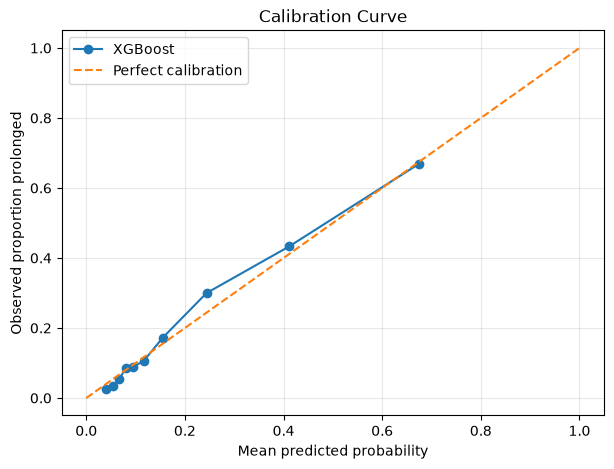

In [672]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion prolonged")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [673]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_test,
    y_test_prob
)

print("Brier score:", brier)

Brier score: 0.11651942878961563


In [674]:
baseline_probability = y_train.mean()

baseline_predictions = [baseline_probability] * len(y_test)

baseline_brier = brier_score_loss(
    y_test,
    baseline_predictions
)

print("Model Brier score:", brier)
print("Baseline Brier score:", baseline_brier)

Model Brier score: 0.11651942878961563
Baseline Brier score: 0.15817646708604066


### Brier Score Interpretation

The Brier score measures the accuracy of predicted probabilities by comparing each predicted probability with the observed outcome.

Lower values indicate better probabilistic predictions, with a perfect score equal to 0.

The tuned XGBoost model achieved a Brier score of approximately 0.117, compared with approximately 0.158 for a baseline model that predicts the overall event prevalence for every patient.

This indicates that the model provides more informative probability estimates than simply assigning the same baseline risk to all patients.

The Brier score evaluates overall probability accuracy and should be interpreted together with the calibration plot and discrimination metrics such as ROC-AUC and PR-AUC.

## Model Interpretation with SHAP

The final XGBoost model demonstrated useful discrimination and reasonable probability performance, but predictive performance alone does not explain how the model arrives at its predictions.

SHAP (SHapley Additive exPlanations) will be used to estimate the contribution of each predictor to the model's output.

SHAP can help answer two complementary questions:

- **Global interpretation:** Which variables are most influential across the dataset?
- **Local interpretation:** Why did the model assign a particular patient a high or low predicted risk?

SHAP values describe model behavior and association, not causation.

In [675]:
import shap

In [676]:
fitted_preprocessor = best_xgb_model.named_steps["preprocessor"]
fitted_xgb = best_xgb_model.named_steps["model"]

X_test_transformed = fitted_preprocessor.transform(X_test)

In [677]:
feature_names = fitted_preprocessor.get_feature_names_out()

feature_names[:20], len(feature_names)

(array(['continuous__age', 'continuous__heart_rate_mean',
        'continuous__mbp_mean', 'continuous__resp_rate_mean',
        'continuous__spo2_mean', 'continuous__hemoglobin_min',
        'continuous__platelets_min', 'continuous__wbc_max',
        'continuous__bicarbonate_min', 'continuous__bun_max',
        'continuous__creatinine_max', 'continuous__glucose_max',
        'continuous__sodium_min', 'continuous__potassium_max',
        'continuous__inr_max', 'continuous__gcs_min',
        'continuous__urine_output_24h',
        'continuous__vasoactive_agent_count_24h',
        'binary__invasive_vent_24h', 'binary__invasive_vent_at_24h'],
       dtype=object),
 63)

In [678]:
explainer = shap.TreeExplainer(fitted_xgb)

shap_values = explainer(X_test_transformed)

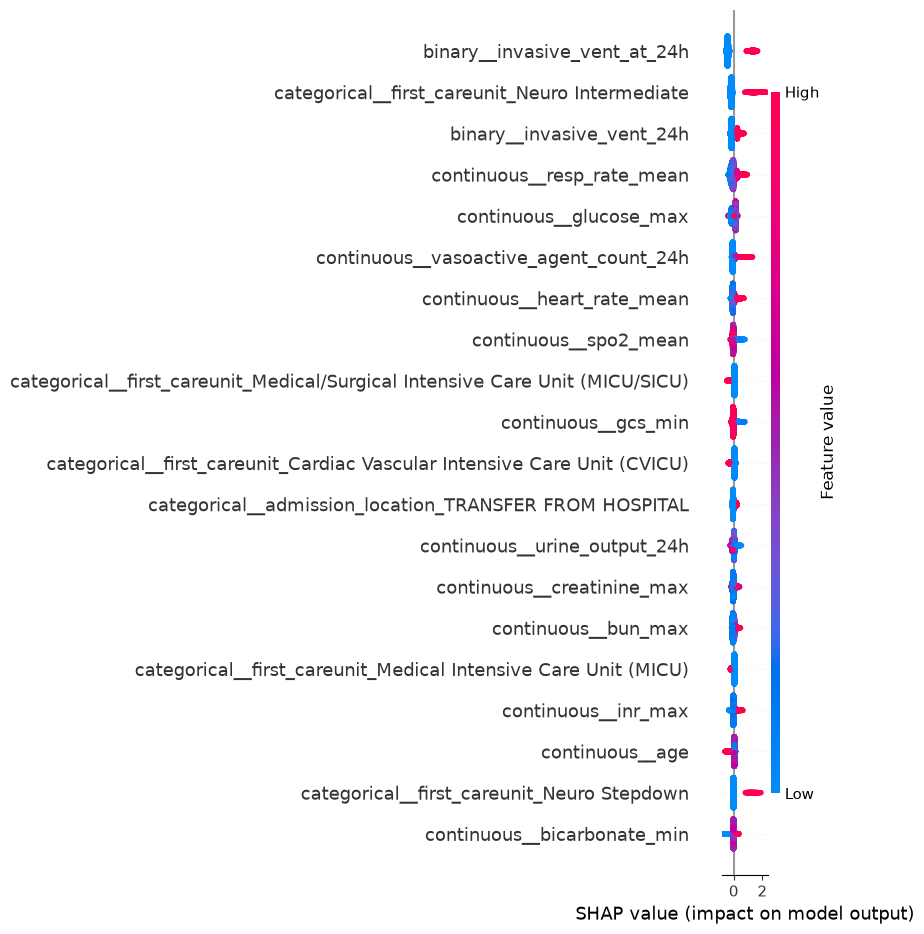

In [679]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20
)

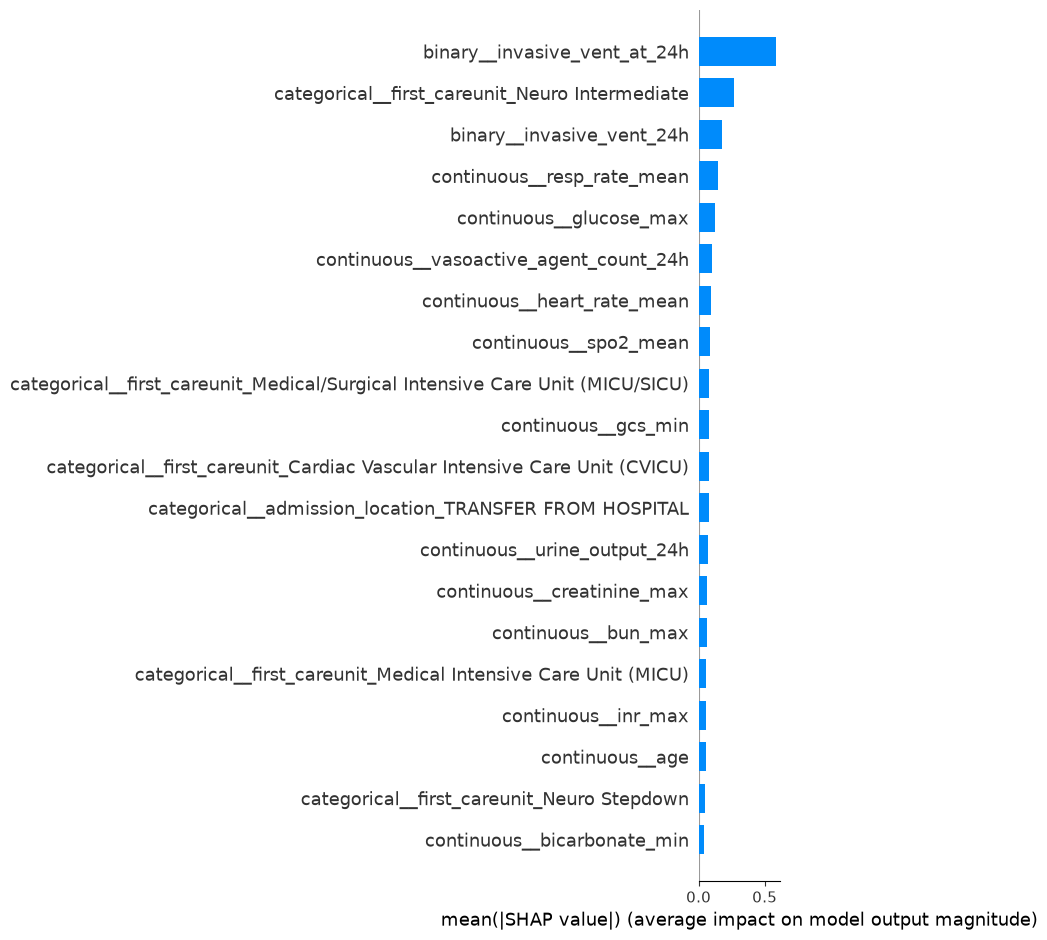

In [680]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

## Save Final Model

The finalized machine-learning pipeline includes both preprocessing and the tuned XGBoost classifier.

Saving the complete pipeline ensures that future predictions use exactly the same:

- missing-value imputation
- numerical scaling
- categorical encoding
- trained XGBoost model

This is especially important for deployment because the web application should receive raw clinical inputs and apply the same transformations used during model development.

In [681]:
import joblib

joblib.dump(
    best_xgb_model,
    "../models/prolonged_icu_xgb_pipeline.pkl"
)

['../models/prolonged_icu_xgb_pipeline.pkl']

In [682]:
import os

model_path = "../models/prolonged_icu_xgb_pipeline.pkl"

print("Model exists:", os.path.exists(model_path))
print("Model size (MB):", round(os.path.getsize(model_path) / 1024**2, 2))

Model exists: True
Model size (MB): 1.12


In [683]:
loaded_model = joblib.load(
    "../models/prolonged_icu_xgb_pipeline.pkl"
)

loaded_prob = loaded_model.predict_proba(
    X_test.iloc[:5]
)[:, 1]

loaded_prob

array([0.10025401, 0.22687204, 0.08809477, 0.1346777 , 0.08266425],
      dtype=float32)

In [684]:
original_prob = best_xgb_model.predict_proba(
    X_test.iloc[:5]
)[:, 1]

print("Original:", original_prob)
print("Reloaded:", loaded_prob)

Original: [0.10025401 0.22687204 0.08809477 0.1346777  0.08266425]
Reloaded: [0.10025401 0.22687204 0.08809477 0.1346777  0.08266425]
